
# Day 28 — RBF Kernel & SVM Regression

1. Explain **similarity features**.
2. Understand the **Gaussian RBF (Radial Basis Function) kernel**.
3. Explain what **gamma (γ)** controls.
4. Understand how **gamma and C affect model complexity**.
5. Use an RBF SVM for nonlinear classification.
6. Use **SVR** for nonlinear regression.
7. Recognize underfitting vs. overfitting caused by hyperparameters.



## 1. The big picture

A linear SVM learns a linear decision boundary:

\[
w^T x + b = 0
\]

Many datasets are not linearly separable. The **kernel trick** allows an SVM to behave as though the data were transformed into a higher-dimensional feature space without explicitly creating every transformed feature.

The Gaussian RBF kernel is:

\[
K(x,x') = \exp(-\gamma ||x-x'||^2)
\]

Intuition:

- Nearby points → high similarity, close to **1**
- Distant points → low similarity, close to **0**
- **gamma** controls how quickly similarity falls with distance.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score

np.random.seed(42)



## 2. Similarity features

Suppose we create a **landmark** at a particular location.

For every input point, we calculate how similar it is to that landmark:

\[
\phi_\gamma(x,\ell)
=
\exp(-\gamma ||x-\ell||^2)
\]

where:

- \(x\) = input point
- \(\ell\) = landmark
- \(||x-\ell||^2\) = squared distance
- \(\gamma\) = controls the width of the Gaussian

Close to the landmark → similarity near 1.

Far from the landmark → similarity approaches 0.


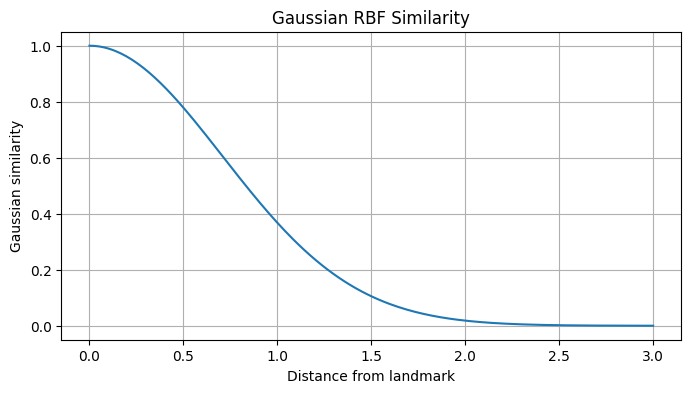

In [2]:

def gaussian_similarity(x, landmark, gamma=1.0):
    distance_squared = np.sum((x - landmark) ** 2)
    return np.exp(-gamma * distance_squared)

landmark = np.array([0.0, 0.0])
distances = np.linspace(0, 3, 200)
similarities = np.exp(-1.0 * distances**2)

plt.figure(figsize=(8, 4))
plt.plot(distances, similarities)
plt.xlabel("Distance from landmark")
plt.ylabel("Gaussian similarity")
plt.title("Gaussian RBF Similarity")
plt.grid(True)
plt.show()


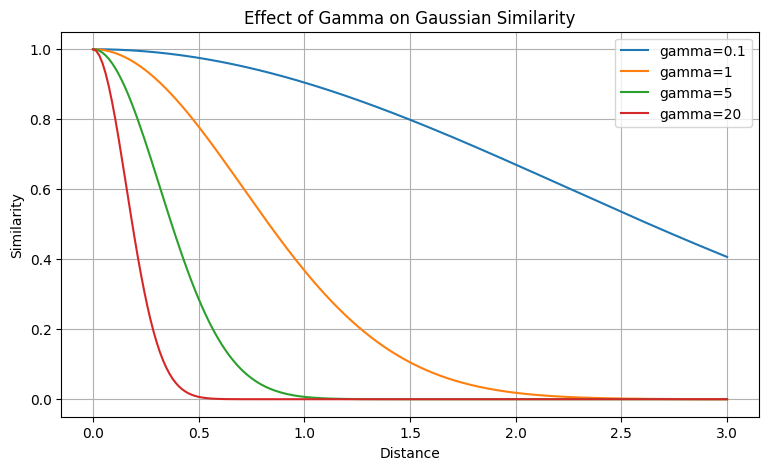

In [3]:

gammas = [0.1, 1, 5, 20]

plt.figure(figsize=(9, 5))

for gamma in gammas:
    similarities = np.exp(-gamma * distances**2)
    plt.plot(distances, similarities, label=f"gamma={gamma}")

plt.xlabel("Distance")
plt.ylabel("Similarity")
plt.title("Effect of Gamma on Gaussian Similarity")
plt.legend()
plt.grid(True)
plt.show()



## 3. What does gamma do?

The RBF kernel is:

\[
K(x,x') = \exp(-\gamma ||x-x'||^2)
\]

### Small gamma

Similarity decreases slowly with distance.

- Each point has influence over a larger region.
- The decision boundary tends to be smoother.
- The model is generally less complex.
- Too small → possible **underfitting**.

### Large gamma

Similarity decreases very quickly.

- Each point has influence over a small region.
- The boundary can become highly irregular.
- The model is more complex.
- Too large → possible **overfitting**.

### Mental model

**Gamma = how local the model is.**

- Low gamma → broad influence
- High gamma → very local influence



## 4. RBF kernel on a nonlinear dataset

The `make_moons` dataset contains curved classes, so a straight line cannot separate them well.


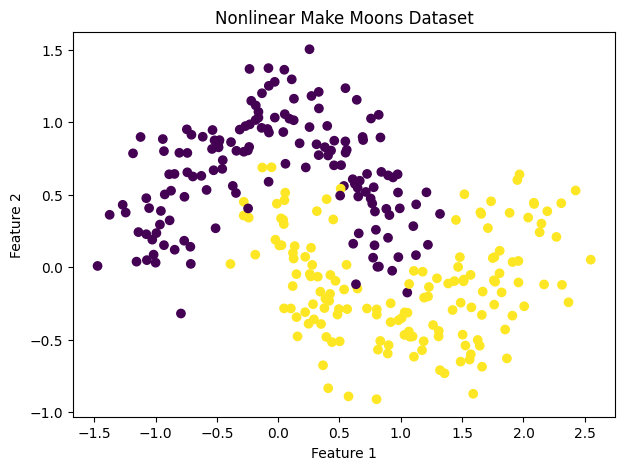

In [4]:

X, y = make_moons(n_samples=300, noise=0.20, random_state=42)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Nonlinear Make Moons Dataset")
plt.show()


In [5]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

rbf_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=5, gamma="scale"))
])

rbf_svm.fit(X_train, y_train)

y_pred = rbf_svm.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, y_pred):.3f}")


Test accuracy: 0.973



## 5. Visualize the nonlinear decision boundary


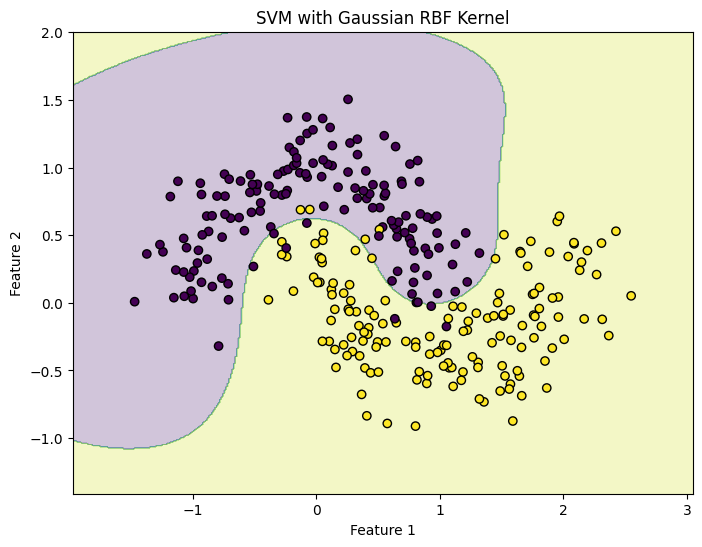

In [6]:

def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, zz, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)
    plt.show()

plot_decision_boundary(
    rbf_svm, X, y, "SVM with Gaussian RBF Kernel"
)



## 6. Gamma and model complexity

Try:

- `gamma=0.01`
- `gamma=0.1`
- `gamma=1`
- `gamma=10`
- `gamma=100`

Watch how the decision boundary changes.

| Gamma | Influence | Boundary | Risk |
|---|---|---|---|
| Very low | Wide | Smooth | Underfitting |
| Moderate | Balanced | Flexible | Often good |
| Very high | Very local | Irregular | Overfitting |

Gamma controls the **locality and flexibility** of the RBF model.


In [7]:

gammas = [0.01, 0.1, 1, 10, 100]

for gamma in gammas:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=5, gamma=gamma))
    ])
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    print(
        f"gamma={gamma:>6} | "
        f"train accuracy={train_acc:.3f} | "
        f"test accuracy={test_acc:.3f}"
    )


gamma=  0.01 | train accuracy=0.867 | test accuracy=0.827
gamma=   0.1 | train accuracy=0.893 | test accuracy=0.880
gamma=     1 | train accuracy=0.978 | test accuracy=0.973
gamma=    10 | train accuracy=0.996 | test accuracy=0.920
gamma=   100 | train accuracy=1.000 | test accuracy=0.893



## 7. Gamma + C together

Recall:

**C** controls how strongly the model penalizes training errors.

**Gamma** controls how local/flexible the RBF influence becomes.

A useful mental model:

- **C** → "How much should I care about training mistakes?"
- **gamma** → "How local should each training point's influence be?"

High `C` + high `gamma` can create a very flexible model and therefore a higher overfitting risk.

In practice, `C` and `gamma` are commonly tuned together using cross-validation.


In [8]:

settings = [
    (0.1, 0.1),
    (1, 0.1),
    (10, 0.1),
    (1, 1),
    (10, 1),
    (1, 10),
    (10, 10),
]

for C, gamma in settings:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=C, gamma=gamma))
    ])
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    print(
        f"C={C:<5} gamma={gamma:<5} "
        f"train={train_acc:.3f} test={test_acc:.3f}"
    )


C=0.1   gamma=0.1   train=0.867 test=0.827
C=1     gamma=0.1   train=0.880 test=0.840
C=10    gamma=0.1   train=0.898 test=0.880
C=1     gamma=1     train=0.969 test=0.960
C=10    gamma=1     train=0.982 test=0.947
C=1     gamma=10    train=0.982 test=0.947
C=10    gamma=10    train=0.996 test=0.907



# 8. SVM Regression

SVMs can also be used for regression.

Scikit-learn provides:

```python
SVR
```

Instead of finding a classification boundary, SVR tries to fit a function while allowing a margin of tolerance around predictions.

The important parameter here is **epsilon**:

\[
|y-f(x)| \leq \epsilon
\]

Errors inside this epsilon-tube are tolerated.

- Smaller epsilon → tighter tolerance
- Larger epsilon → wider tolerance


In [9]:

rng = np.random.RandomState(42)

X_reg = np.linspace(-3, 3, 250).reshape(-1, 1)
y_reg = (
    0.5 * X_reg.ravel()**3
    - 1.5 * X_reg.ravel()
    + rng.normal(0, 1.0, size=len(X_reg))
)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)

svr = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf", C=10, gamma="scale", epsilon=0.2))
])

svr.fit(Xr_train, yr_train)

yr_pred = svr.predict(Xr_test)

print("RMSE:", mean_squared_error(yr_test, yr_pred) ** 0.5)
print("R²:", r2_score(yr_test, yr_pred))


RMSE: 0.8232296731502765
R²: 0.9258358395146813


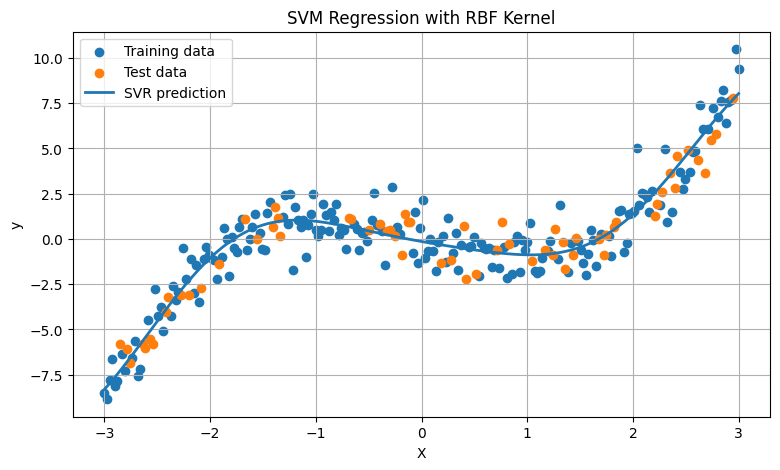

In [10]:

x_plot = np.linspace(X_reg.min(), X_reg.max(), 500).reshape(-1, 1)
y_plot = svr.predict(x_plot)

plt.figure(figsize=(9, 5))
plt.scatter(Xr_train, yr_train, label="Training data")
plt.scatter(Xr_test, yr_test, label="Test data")
plt.plot(x_plot, y_plot, linewidth=2, label="SVR prediction")
plt.xlabel("X")
plt.ylabel("y")
plt.title("SVM Regression with RBF Kernel")
plt.legend()
plt.grid(True)
plt.show()


## 9. Experiment with epsilon (detailed explanation)

The parameter `epsilon` defines an "epsilon-tube" (an insensitive region) around the predicted function where errors are ignored.

Key points:

- Definition (per-example loss):

  $L_{\epsilon}(y, f(x)) = \max(0,\; |y - f(x)| - \epsilon)$

  - If the absolute error $|y - f(x)| \le \epsilon$, the loss is 0 (the prediction falls inside the epsilon-tube).
  - If $|y - f(x)| > \epsilon$, the loss equals the excess beyond the tube.

- Intuition:
  - **Small epsilon** (e.g. `0.05`): the tube is narrow → many deviations fall outside the tube and incur penalties. The model must fit the data more closely (lower bias, higher variance risk).
  - **Large epsilon** (e.g. `1.0`): the tube is wide → small/medium deviations are ignored and do not affect the loss. The model can be smoother (higher bias, lower variance).

- Interaction with `C` (regularization):
  - SVR objective balances model simplicity (`0.5 * ||w||^2`) and summed losses outside the tube scaled by `C`.
  - **Large `C` + small `epsilon`** → strongly penalize even small deviations → tight fit (possible overfitting).
  - **Small `C` + large `epsilon`** → tolerate many deviations → smooth fit (possible underfitting).

- Practical tips:
  - Choose `epsilon` in the units of your target variable (if measurement noise ≈ 0.2, start near 0.2).
  - Use cross-validation to tune `(C, gamma, epsilon)` together.
  - Inspect the number of support vectors: larger `epsilon` → typically fewer support vectors (more points lie inside the tube).

In [11]:

epsilons = [0.05, 0.2, 0.5, 1.0]

for epsilon in epsilons:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(
            kernel="rbf",
            C=10,
            gamma="scale",
            epsilon=epsilon
        ))
    ])

    model.fit(Xr_train, yr_train)
    pred = model.predict(Xr_test)

    rmse = mean_squared_error(yr_test, pred) ** 0.5
    print(f"epsilon={epsilon:<4} | test RMSE={rmse:.3f}")


epsilon=0.05 | test RMSE=0.849
epsilon=0.2  | test RMSE=0.823
epsilon=0.5  | test RMSE=0.830
epsilon=1.0  | test RMSE=0.786



# 11. RBF kernel vs. polynomial kernel

| Feature | Polynomial kernel | RBF kernel |
|---|---|---|
| Main idea | Polynomial relationships | Similarity based on distance |
| Important parameters | degree, C | gamma, C |
| Flexibility | Controlled by degree | Strongly controlled by gamma |
| Local behavior | Less local | Very local when gamma is large |
| Common use | Polynomial-like structure | General-purpose nonlinear problems |

A practical rule:

> RBF is often the first nonlinear kernel to try when you do not have a strong reason to choose another kernel.
